# Online Forum Multi-Label Communicative Type Classification

We classify casual online forum comments written in Bahasa Melayu, English, and Manglish from Lowyat Kopitiam based on what the user is trying to communicate.


# The 6 Categories

- **Inquiry**: Questions, seeking help, recommendations, or troubleshooting.
- **Complaint**: Venting frustration, complaining about bad service, high prices, or problems.
- **Opinion**: Personal viewpoints, beliefs, reviews, or arguments.
- **Information**: Objective facts, news, official updates, guides, or links.
- **Expressive**: Jokes, laughing, memes, greetings, or casual banter.
- **Spam**: Unwanted promotional links, referral links, or automated bot posts.


Because a single forum comment can serve multiple purposes, we use **Multi-Label Classification**.


The raw Lowyat forum records are from Hugging Face

https://huggingface.co/datasets/malaysia-ai/crawl-lowyat/resolve/main/kopitiam.json

Then, we use generative AI to help us to classify the records, and save the results in `dataset.csv`

# 0.0 Environment Setup & Configuration
Install necessary dependencies and suppress external library warnings to ensure clean notebook execution.

## 0.1 Install Required Libraries
Install all necessary third-party Python packages for text processing, feature extraction, modeling, and visualization.

In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 0.2 Suppress Warnings
Configure warning filters to suppress non-critical deprecation and regex notifications from external libraries for clean notebook execution.

In [1]:
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 1.0 Pre-processing: High-Speed Regex Masking & Formatting

In this stage, we inspect the raw Lowyat forum dataset and perform regex-based noise cleaning, quote stripping, signature removal, and entity masking.

## 1.1 Initial Dataset Inspection
We load the raw dataset to examine the total volume, multi-label communicative class columns, and sample forum posts.

In [2]:
import pandas as pd

data = pd.read_csv("dataset.csv", encoding="utf-8")

print("Total rows in the dataset: ", data.shape[0])

print("First 5 rows of the dataset: ")
display(pd.DataFrame(data.head(5)))

print("Last 5 rows of the dataset: ")
display(pd.DataFrame(data.tail(5)))

Total rows in the dataset:  99106
First 5 rows of the dataset: 


,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
0,1,Konfem puting hitam hehhe,0,0,0,0,1,0
1,2,the feast starts now!,0,0,0,0,1,0
2,3,Shake shake 5pm\n\nhttps://games.shopee.com.my...,0,0,0,1,0,1
3,4,Situasi dlm keta\n\nKau : padu betul\n\nDia : ...,0,0,0,0,1,0
4,5,currently he is playing for india?\nwooooh.......,1,0,0,0,1,0


Last 5 rows of the dataset: 


,id,text,Inquiry,Complaint,Opinion,Information,Expressive,Spam
99101,99102,Sendiri bodo no wonder miskin kek,0,0,1,0,1,0
99102,99103,Removed\n\nThis post has been edited by Pretty...,0,0,0,0,0,0
99103,99104,"QUOTE(Mr Mercedes @ Mar 10 2023, 05:58 PM)Nobo...",0,0,1,1,0,0
99104,99105,Topkek dah berapa bulan masih x launch.,0,1,1,0,1,0
99105,99106,cny now ka?,1,0,0,0,0,0


## 1.2 Quote Block & Signature Removal


We strip forum quote headers and Lowyat edit signatures to prevent metadata and duplicate quotes from biasing intent classification.

In [3]:
import re

QUOTE_REGEX = re.compile(
    r"QUOTE\s*\([\s\S]*?\)|\[QUOTE[\s\S]*?\[/QUOTE\]", re.IGNORECASE
)
EDIT_SIG_REGEX = re.compile(r"This post has been edited by.*?(?=\n|$)", re.IGNORECASE)


def remove_quotes(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return QUOTE_REGEX.sub("", text)


def remove_lowyat_edit_signatures(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return EDIT_SIG_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: remove_quotes(x))
print(
    "Number of rows affected by quote removal: ", (original_texts != data["text"]).sum()
)

original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: remove_lowyat_edit_signatures(x))
print(
    "Total rows affected by lowyat edit signature removal: ",
    (original_texts != data["text"]).sum(),
)

Number of rows affected by quote removal:  44778
Total rows affected by lowyat edit signature removal:  8036


## 1.3 Special Element Masking

Replace specific entities with generic placeholder tags so sentence structure stays intact without leaving raw noise
- URLs & Links: `https://...` $\rightarrow$ `<URL>`
- Phone Numbers: `012-3456789, +6017...` $\rightarrow$ `<PHONE>`
- Prices / Currency: `RM150, $20` $\rightarrow$ `<PRICE>`
- Timestamps: `02:30 PM, 14:00` $\rightarrow$ `<TIME>`

### 1.3.1 Mask URL & Links


We replace web links and domain URLs with `<URL>` tokens to reduce vocabulary sparsity.

In [4]:
URL_REGEX = re.compile(
    r"(https?://[^\s]+|www\.[^\s]+|[a-zA-Z0-9-]+\.[a-zA-Z]{2,24}[^\s]*)",
    re.IGNORECASE,
)


def mask_urls(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return URL_REGEX.sub(" <URL> ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_urls(x))

print("Total rows affected by masking URLs: ", (original_texts != data["text"]).sum())

Total rows affected by masking URLs:  10776


### 1.3.2 Mask Phone Numbers


We detect and mask Malaysian phone numbers using the `phonenumbers` library into `<PHONE>` tokens.

In [5]:
import phonenumbers

def mask_phone_numbers(text, default_region="MY"):
    if not isinstance(text, str) or not text.strip():
        return ""

    for match in phonenumbers.PhoneNumberMatcher(text, default_region):
        phone_str = text[match.start : match.end]
        text = text.replace(phone_str, " <PHONE> ")

    return text


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_phone_numbers(x))

print(
    "Total rows affected by masking phone numbers: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking phone numbers:  100


### 1.3.3 Mask Prices


We dynamically match global and regional currency symbols (e.g., RM, MYR, S$, USD) and convert financial amounts to `<PRICE>` tokens.

In [6]:
from price_parser.parser import CURRENCY_SYMBOLS

all_symbols = set(CURRENCY_SYMBOLS)

# Add localized currency representations commonly used in regional forums
all_symbols.update(["RM", "rm", "MYR", "myr", "S$", "A$", "HK$", "NT$"])

print("All currency symbols to be masked: ", all_symbols)

All currency symbols to be masked:  {'Nu.', '₡', 'Rp', 'KHR', 'IRR', 'лв', 'IQD', 'MURs', 'Nkr', 'XPT', 'CA$', 'RUB', 'MKD', 'Lt', 'CFA', '₩', 'AED', 'fr.', 'zł', 'CF', 'FBu', 'NZ$', 'XXX', 'XBA', 'Afl.', 'L', 'D', 'FIM', 'CHF', 'SSP', 'GEL', 'ZK', 'GTQ', 'BD', 'TSh', 'T', 'G', '₪', 'YR', 'Db', 'Kz', 'GH₵', 'Af', 'CYP', 'Pta', 'CFP', 'KZT', 'WS$', 'Ls', 'DM', 'R', 'XTS', 'XUA', 'BZ$', 'MYR', 'HNL', '₦', 'kn', 'SR', 'RM', 'S/.', 'PKRs', 'XBB', 'FG', 'Ikr', 'Le', 'CO$', 'F', 'Bds$', '-', 'C$', 'NT$', '₭', 'R$', 'XAG', 'XBC', 'MMK', 'öS', 'Lm', 'Rs', '₫', 'N$', 'QR', 'Ft', 'AU$', 'AMD', 'CV$', 'fl.', '€', 'SY£', 'UM', 'Skr', 'ƒ', 'SKK', 'Tk', 'S$', 'BWP', 'LD', 'EGP', 'MGA', 'Z$', 'руб', 'Bs.F.', 'UF', 'MK', 'XBD', 'RD$', 'MRf', 'Kč', 'MOP$', '฿', '₲', 'SDG', 'MTn', 'din.', 'BN$', 'Ssh', 'GRD', 'B/.', 'rm', 'XAU', 'XDR', 'TT$', 'RWF', 'man.', 'Fdj', 'IR£', 'KD', 'myr', 'Dkr', 'MDL', 'UYI', '$U', 'NPRs', 'KM', 'UZS', 'CUC$', 'MAD', 'K', 'AR$', 'CL$', '₨', 'TL', '¥', 'VT', 'J$', 'CDF', 'OMR

In [7]:
from price_parser.parser import CURRENCY_SYMBOLS

# Filter out dangerous single alphabetic letters (e.g. 'w', 's', 'k')
# Keep multi-letter currencies ('RM', 'MYR', 'USD') and actual symbols ('$', '€')
safe_symbols = {s for s in all_symbols if len(s) > 1 or not s.isalpha()}

# Compile sorted regex pattern with word boundaries
escaped_symbols = [re.escape(s) for s in sorted(safe_symbols, key=len, reverse=True)]
DYNAMIC_CURRENCY_PATTERN = "|".join(escaped_symbols)

PRICE_REGEX = re.compile(
    rf"(?:(?:\b|\s)(?:{DYNAMIC_CURRENCY_PATTERN})\s*\d+(?:[\.,]\d+)?\b|\b\d+(?:[\.,]\d+)?\s*(?:{DYNAMIC_CURRENCY_PATTERN})\b)",
    re.IGNORECASE,
)


def mask_prices(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    return PRICE_REGEX.sub(" <PRICE> ", text)


# Apply to dataset
original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_prices(x))

print("Total rows affected by masking prices: ", (original_texts != data["text"]).sum())

Total rows affected by masking prices:  8845


### 1.3.4 Mask Timestamps


We extract 12-hour and 24-hour timestamp patterns and mask them with `<TIME>` tokens.

In [8]:
TIME_REGEX = re.compile(
    r"\b(?:1[0-2]|0?[1-9]):[0-5][0-9]\s?(?:[AaPp][Mm])?\b|\b(?:[01]?[0-9]|2[0-3]):[0-5][0-9]\b"
)


def mask_times(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return TIME_REGEX.sub(" <TIME> ", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(lambda x: mask_times(x))

print(
    "Total rows affected by masking timestamps: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by masking timestamps:  313


## 1.4 Emoji Conversion


We convert graphical unicode emojis into explicit descriptive text tags using `emoji.demojize` to preserve emotional communicative intent.

In [9]:
import emoji


def convert_emojis(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return emoji.demojize(text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(convert_emojis)

print(
    "Total rows affected by emoji conversion: ", (original_texts != data["text"]).sum()
)

Total rows affected by emoji conversion:  3124


## 1.5 Lowercasing


We convert all characters to lowercase to eliminate case sensitivity across all words and tokens.

In [10]:
def to_lower(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return text.lower()


data["text"] = data["text"].apply(to_lower)

## 1.6 Filter Non-Latin Characters


We remove non-ASCII and non-Latin character sets (such as Chinese, Tamil, Arabic, or Cyrillic characters) to focus on the Malay/English forum corpus.

In [11]:
NON_LATIN_REGEX = re.compile(r"[^\x00-\x7F]+")


def strip_non_latin(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    return NON_LATIN_REGEX.sub("", text)


original_texts = data["text"].copy()
data["text"] = data["text"].apply(strip_non_latin)

print(
    "Total rows affected by stripping non-Latin: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by stripping non-Latin:  8400


## 1.7 Elongated Character & Symbol Reduction


We reduce characters repeated 3 or more times down to 2 and collapse consecutive punctuation marks down to a single mark.

In [12]:
# Reduces 3+ repeating letters/characters down to 2
REPEAT_CHAR_REGEX = re.compile(r"(.)\1{2,}", re.IGNORECASE)

# Reduces 2+ repeating punctuation marks down to 1
REPEAT_PUNCT_REGEX = re.compile(r"([!?.])\1+", re.IGNORECASE)

def reduce_elongated(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = REPEAT_CHAR_REGEX.sub(r"\1\1", text)
    text = REPEAT_PUNCT_REGEX.sub(r"\1", text)

    return text.strip()

original_texts = data["text"].copy()
data["text"] = data["text"].apply(reduce_elongated)

print(
    "Total rows affected by elongation reduction: ",
    (original_texts != data["text"]).sum(),
)

Total rows affected by elongation reduction:  38646


# 2.0 Pre-processing: Tokenization & Slang Normalization


In this stage, we standardize Malaysian code-mixed informal text by loading and merging slang dictionaries to map short-forms to canonical root words.

## 2.1 Sentence Tokenization


We segment posts into lists of individual sentences using NLTK's `sent_tokenize` to prepare structured text units for linguistic normalization.

In [13]:
import nltk

# Ensure required NLTK tokenization models are downloaded
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    print("Downloading NLTK punkt_tab tokenizer...")
    nltk.download("punkt_tab", quiet=True)

In [14]:
from nltk.tokenize import sent_tokenize


def tokenize_sentences(text):
    if not isinstance(text, str) or not text.strip():
        return []

    return sent_tokenize(text)


original_texts = data["text"].copy()
tokenized_sentences = data["text"].apply(tokenize_sentences)

total_posts = len(tokenized_sentences)
total_sentences = tokenized_sentences.apply(len).sum()

print("Total sentences extracted across dataset: ", total_sentences)

Total sentences extracted across dataset:  290798


## 2.2 Pre-built Internet Slang Normalization

We get the english slang dictionary from https://github.com/cbaziotis/ekphrasis/blob/master/ekphrasis/dicts/noslang/slangdict.py, then save it as `slangdict.json`


We load standard English internet slang mappings from `slangdict.json` and perform multi-word regex substitution and token-level replacement.

In [15]:
import json

english_slangdict = json.load(open("slangdict.json", "r", encoding="utf-8"))

print("Total English Slang entries:", len(english_slangdict))
print("Examples of English Slang entries:")
for k, v in list(english_slangdict.items())[:5]:
    print("  ", k, "->", v)

Total English Slang entries: 5439
Examples of English Slang entries:
   k4u -> Kiss for you
   67 -> unknown
   07734 -> hello
   0day -> software illegally obtained before it was released
   0noe -> Oh No


In [16]:
SLANG_MAP = {k.lower(): str(v) for k, v in english_slangdict.items() if k}

# 2. Separate multi-word keys (e.g. "what the heck") from single-word keys
multi_word_keys = [k for k in SLANG_MAP.keys() if " " in k]
multi_word_keys.sort(key=len, reverse=True)

# Tiny regex ONLY for multi-word phrases (super fast because it's small)
MULTI_WORD_REGEX = None
if multi_word_keys:
    MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(k) for k in multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )

# Regex to safely separate outside punctuation from the core word
# e.g., "a/b," -> prefix:"", core:"a/b", suffix:","
EDGE_PUNCT_REGEX = re.compile(r"^([^\w]*)(.*?)([^\w]*)$")


def normalize_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # Pass 1: Handle multi-word slang instantly
    if MULTI_WORD_REGEX:
        text = MULTI_WORD_REGEX.sub(
            lambda m: SLANG_MAP.get(m.group(0).lower(), m.group(0)), text
        )

    # Pass 2: Handle single-word slang with symbols
    # Split strictly by whitespace (keeps internal symbols like '/' or '\' intact)
    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()

        # Check if exact token is in dictionary first
        if lower_token in SLANG_MAP:
            normalized_tokens.append(SLANG_MAP[lower_token])
            continue

        # Extract prefix, core word, and suffix punctuation
        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()

            if lower_core in SLANG_MAP:
                # Reassemble the word with its original outside punctuation
                normalized_tokens.append(f"{prefix}{SLANG_MAP[lower_core]}{suffix}")
                continue

        # If no match found, keep original token
        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_english_sentences = tokenized_sentences.apply(
    lambda sentence_list: [
        normalize_slang_bulletproof(sent) for sent in sentence_list
    ]
)

sentences_affected = sum(
    orig_sent != norm_sent
    for orig_list, norm_list in zip(
        tokenized_sentences, normalized_english_sentences
    )
    for orig_sent, norm_sent in zip(orig_list, norm_list)
)

print(
    "Total sentences affected by English slang normalization: ",
    sentences_affected,
)

Total sentences affected by English slang normalization:  102695


## 2.3 Malay Probabilistic Normalization

We get the malay slang dictionary from https://data.mendeley.com/datasets/mgv2n2vcb9/3/files/a7b86a2f-1175-4ff0-b813-d95218534cd4, which we save as `malayslangdict.json`.




We load and merge standard Malay slang dictionaries (`malayslangdict.json`) and project-specific mappings (`custom_malay_slang.json`) to standardize informal Malay short-forms.

In [17]:
malay_slang_1 = json.load(open("malayslangdict.json", "r", encoding="utf-8"))
malay_slang_2 = json.load(open("custom_malay_slang.json", "r", encoding="utf-8"))

malay_slangdict = {**malay_slang_1, **malay_slang_2}

print("Total Malay Slang entries:", len(malay_slangdict))
print("Examples of Malay Slang entries:")
for k, v in list(malay_slangdict.items())[:5]:
    print("  ", k, "->", v)

Total Malay Slang entries: 1476
Examples of Malay Slang entries:
   2 -> itu
   6be -> nombor
   abeh -> habis
   abes -> habis
   abih -> habis


In [18]:
SLANG_MAP = {
    str(k).lower(): str(v)
    for k, v in malay_slangdict.items()
    if k and str(k).lower() != str(v).lower()
}

# Extract multi-word terms (e.g., "tak tahu", "apa benda", "dia orang")
multi_word_keys = [k for k in SLANG_MAP.keys() if " " in k]
multi_word_keys.sort(key=len, reverse=True)

# Small regex ONLY for multi-word phrases
MULTI_WORD_REGEX = None
if multi_word_keys:
    MULTI_WORD_REGEX = re.compile(
        r"\b(" + "|".join(re.escape(k) for k in multi_word_keys) + r")\b",
        flags=re.IGNORECASE,
    )

# Edge punctuation regex to peel off outside symbols like ',' or '?'
EDGE_PUNCT_REGEX = re.compile(r"^([^\w]*)(.*?)([^\w]*)$")


def normalize_malay_slang_bulletproof(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # Pass 1: Handle multi-word slang (e.g. "xtau" -> "tak tahu" or "apa benda" -> "amende")
    if MULTI_WORD_REGEX:
        text = MULTI_WORD_REGEX.sub(
            lambda m: SLANG_MAP.get(m.group(0).lower(), m.group(0)), text
        )

    # Pass 2: Tokenize by whitespace (preserves inner symbols like '/', '\', '-')
    tokens = text.split()
    normalized_tokens = []

    for token in tokens:
        lower_token = token.lower()

        # Direct exact match check
        if lower_token in SLANG_MAP:
            normalized_tokens.append(SLANG_MAP[lower_token])
            continue

        # Strip outside punctuation and check core word
        match = EDGE_PUNCT_REGEX.match(token)
        if match:
            prefix, core, suffix = match.groups()
            lower_core = core.lower()

            if lower_core in SLANG_MAP:
                normalized_tokens.append(f"{prefix}{SLANG_MAP[lower_core]}{suffix}")
                continue

        normalized_tokens.append(token)

    return " ".join(normalized_tokens)


normalized_malay_sentences = normalized_english_sentences.apply(
    lambda sentence_list: [
        normalize_malay_slang_bulletproof(sent) for sent in sentence_list
    ]
)

sentences_affected = sum(
    orig_sent != norm_sent
    for orig_list, norm_list in zip(
        normalized_english_sentences, normalized_malay_sentences
    )
    for orig_sent, norm_sent in zip(orig_list, norm_list)
)

print(
    "Total sentences affected by Malay slang normalization: ",
    sentences_affected,
)

Total sentences affected by Malay slang normalization:  115970


## 2.4 Word Tokenization


We break normalized sentence strings into individual word tokens using NLTK's `word_tokenize`.

In [19]:
from nltk.tokenize import word_tokenize


def tokenize_words(sentence_text):
    if not isinstance(sentence_text, str) or not sentence_text.strip():
        return []
    return word_tokenize(sentence_text)


word_tokenized_posts = normalized_malay_sentences.apply(
    lambda sentence_list: [tokenize_words(sent) for sent in sentence_list]
)

total_words = sum(
    len(word) for post in word_tokenized_posts for sentence in post for word in sentence
)

print("Total word tokens generated across dataset: ", total_words)
print("\nSample Word Tokenized Output:")
for i, post in enumerate(word_tokenized_posts.iloc[:5]):
    print(" ", i, ". ", post)

Total word tokens generated across dataset:  15830419

Sample Word Tokenized Output:
  0 .  [['konfem', 'puting', 'hitam', 'hehhe']]
  1 .  [['the', 'feast', 'starts', 'now', '!']]
  2 .  [['shake', 'shake', '5pm', '<', 'url', '>']]
  3 .  [['situasi', 'dalam', 'keta', 'kau', ':', 'padu', 'betul', 'dia', ':', 'padu', 'apa', '?'], ['kau', ':', 'eh', 'bkn.pandu', 'betul', 'betul']]
  4 .  [['currently', 'he', 'is', 'playing', 'for', 'india', '?'], ['wooh.tat', "'s", 'new']]


## 2.5 Punctuation Filtering

Filter out uninformative punctuation tokens (such as commas, colons, and periods) while preserving intent-bearing punctuation (`?`, `!`) and special mask tags (`<URL>`, `<PRICE>`, `<PHONE>`, `<TIME>`).

In [20]:
# Punctuation to retain for communicative intent signals
KEEP_PUNCTUATION = {'?', '!'}

def filter_tokens(post_sentences):
    cleaned_post = []
    for sentence in post_sentences:
        cleaned_sentence = []
        for token in sentence:
            token_str = token.strip()
            
            # 1. Retain special entity tags (<URL>, <PRICE>, etc.)
            if token_str.startswith("<") and token_str.endswith(">"):
                cleaned_sentence.append(token_str)
            # 2. Retain alphanumeric words
            elif token_str.isalnum():
                cleaned_sentence.append(token_str)
            # 3. Retain ONLY intent-bearing punctuation (? and !)
            elif token_str in KEEP_PUNCTUATION:
                cleaned_sentence.append(token_str)
            # All other punctuation ('.', ',', ':', ';', '-', '"') is dropped
            
        if cleaned_sentence:
            cleaned_post.append(cleaned_sentence)
            
    return cleaned_post

# Filter word tokens across all posts
filtered_punct_posts = word_tokenized_posts.apply(filter_tokens)

print("Sample Tokenized Post (After Punctuation Removal):")
for i, post in enumerate(filtered_punct_posts.iloc[:4]):
    print(f" {i} . {post}")

Sample Tokenized Post (After Punctuation Removal):
 0 . [['konfem', 'puting', 'hitam', 'hehhe']]
 1 . [['the', 'feast', 'starts', 'now', '!']]
 2 . [['shake', 'shake', '5pm', 'url']]
 3 . [['situasi', 'dalam', 'keta', 'kau', 'padu', 'betul', 'dia', 'padu', 'apa', '?'], ['kau', 'eh', 'betul', 'betul']]


# 3.0 Pre-processing: Language-Aware Morphological Processing


In this section, we apply language-aware morphological normalization by identifying the language of individual tokens, applying language-specific stemming and lemmatization (Sastrawi for Malay, WordNet for English), and filtering stopwords.

## 3.1 Dictionary Lookups & Language Identification


We tag each token as TAG, PUNCT, MALAY, ENGLISH, or UNKNOWN using Malaya dictionary lookups so that the appropriate language-specific morphological pipeline can be applied.

In [21]:
from malaya.dictionary import is_malay, is_english


def classify_word_lang(token):
    if token.startswith("<") and token.endswith(">"):
        return "TAG"

    if not token.isalnum():
        return "PUNCT"

    if is_malay(token):
        return "MALAY"

    if is_english(token):
        return "ENGLISH"

    return "UNKNOWN"


def classify_post_lang(post):
    return [
        [(token, classify_word_lang(token)) for token in sentence] for sentence in post
    ]


classified_lang_posts = filtered_punct_posts.apply(classify_post_lang)

C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3397
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))
C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3927
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))


## 3.2 Stemming & Lemmatization


We apply cross-lingual morphological normalization to reduce words to their base root forms using Sastrawi for Malay and WordNet for English.

### 3.2.1 Initialize Malaya Sastrawi Stemmer


We initialize the Sastrawi Malay stemmer from the `malaya.stem` library to remove Malay prefixes and suffixes (affixes).

In [22]:
from malaya.stem import sastrawi

# Initialize Malaya Sastrawi Stemmer
sastrawi_stemmer = sastrawi()

# Quick test
print("mementingkan ->", sastrawi_stemmer.stem("mementingkan"))
print("pembelajaran ->", sastrawi_stemmer.stem("pembelajaran"))

mementingkan -> penting
pembelajaran -> ajar


C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\model\stem.py:28: FutureWarning: Possible nested set at position 3
  or re.findall(_expressions['ic'], word.lower())


### 3.2.2 Initialize NLTK WordNet English Lemmatizer


We initialize the NLTK WordNet lemmatizer to convert English words back to their dictionary lemma by checking verb forms first, then noun forms.

In [23]:
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK WordNet corpora are downloaded safely
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    print("Downloading NLTK wordnet...")
    nltk.download("wordnet", quiet=True)

try:
    nltk.data.find("corpora/omw-1.4")
except LookupError:
    print("Downloading NLTK omw-1.4...")
    nltk.download("omw-1.4", quiet=True)

print("NLTK is ready")

NLTK is ready


In [24]:
# Initialize WordNet Lemmatizer
wordnet_lemmatizer = WordNetLemmatizer()


def lemmatize_english_token(token: str) -> str:
    """Lemmatizes an English token by checking verb form first, then noun form."""
    token_lower = token.lower()
    lemma = wordnet_lemmatizer.lemmatize(token_lower, pos="v")
    lemma = wordnet_lemmatizer.lemmatize(lemma, pos="n")
    return lemma

### 3.2.3 Cross-Lingual Stemming and Lemmatization


We route tokens to Sastrawi if tagged as MALAY or WordNet if tagged as ENGLISH, while leaving special tags and punctuation untouched.

In [25]:
def stem_and_lemmatize_token(token, lang_label):
    if lang_label == "MALAY":
        stemmed = sastrawi_stemmer.stem(token)
        return stemmed if stemmed else token

    elif lang_label == "ENGLISH":
        return lemmatize_english_token(token)

    # Return untouched if TAG, PUNCT, or UNKNOWN
    return token


def process_sentence_stem_lemma(sentence_tuples):
    return [
        (stem_and_lemmatize_token(token, lang), lang) for token, lang in sentence_tuples
    ]


def process_post_stem_lemma(post_tuples):
    return [process_sentence_stem_lemma(sentence) for sentence in post_tuples]


stemmed_lemmatized_posts = classified_lang_posts.apply(process_post_stem_lemma)

## 3.3 Stop Word Filtering


We remove common, non-informative Malay and English stopwords to retain only content-bearing terms for the classification models.

### 3.3.1 Build Merged Stopwords


We merge English stopwords from `nltk.corpus` and Malay stopwords from `malaya.text.function` into a unified stopword set.

In [26]:
from nltk.corpus import stopwords as nltk_stopwords
from malaya.text.function import get_stopwords as malaya_stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download("stopwords", quiet=True)

english_stops = set(nltk_stopwords.words("english"))
malay_stops = set(malaya_stopwords())

COMBINED_STOPWORDS = english_stops.union(malay_stops)

print("English Stopwords: ", english_stops)
print("Total English Stopwords: ", len(english_stops))

print("Malay Stopwords: ", malay_stops)
print("Total Malay Stopwords: ", len(malay_stops))

print("Total Combined Stopwords: ", len(COMBINED_STOPWORDS))

English Stopwords:  {"shouldn't", "wouldn't", 'with', 'itself', 'are', 'which', 'if', "that'll", 'only', "should've", 'such', 'these', 'your', 'o', 'yours', 'don', "we'd", 'm', 'and', 'how', 'on', 'doesn', 'no', 'did', 'then', 'himself', 'will', 'mightn', 'some', 'am', 'its', "it's", 'they', 'for', 'my', 're', 'ours', 'wasn', 'as', "i'll", 'll', 'very', "wasn't", "you'd", 'is', 'why', 'here', 'or', "mightn't", 'what', 'having', 'from', 'again', 'yourself', "weren't", "mustn't", "it'd", "she's", 'should', 'shan', 'wouldn', 'than', 'whom', 'aren', 'he', 'while', 'me', "won't", 'before', 'theirs', 'has', 'won', "isn't", "you'll", "it'll", 'been', 'ma', 'under', "you've", 'hadn', 'other', 'it', 'below', 'our', 'most', 'until', 'there', 'few', "she'll", 'above', 'who', 'themselves', 'where', "you're", 'once', "i'd", 'isn', 'nor', 'because', 'up', "i'm", 'both', 'at', 'of', 'were', "couldn't", 'not', 'being', 'be', 'she', "he'll", 'hasn', 'needn', 'about', 'a', "hasn't", 'so', 'i', 'couldn',

### 3.3.2 Stop Word Filtering


We filter out tokens present in the combined stopword list while strictly preserving entity tags and intent-bearing punctuation marks.

In [27]:
def is_stopword_token(token, lang_label):
    global total_stopwords_filtered

    if lang_label == "TAG":
        return False

    if lang_label == "PUNCT":
        return False

    included = token in COMBINED_STOPWORDS

    if included:
        total_stopwords_filtered += 1

    return included


def filter_sentence_stopwords(sentence_tuples):
    return [
        (token, lang)
        for token, lang in sentence_tuples
        if not is_stopword_token(token, lang)
    ]


def filter_post_stopwords(post_tuples):
    cleaned_sentences = [
        filter_sentence_stopwords(sentence) for sentence in post_tuples
    ]

    return [s for s in cleaned_sentences if len(s) > 0]

total_stopwords_filtered = 0
filtered_stopwords_posts = stemmed_lemmatized_posts.apply(filter_post_stopwords)

print("Total Stopwords Filtered: ", total_stopwords_filtered)

Total Stopwords Filtered:  1400433


## 3.4 Flattening Posts

Flatten the nested post structure `[[(token, lang), ...], ...]` into a 1D list of cleaned token strings per post (`['token1', 'token2', ...]`) to finalize the preprocessing pipeline.

In [28]:
def flatten_post_to_tokens(post_tuples):
    tokens = []
    for sentence in post_tuples:
        for token, _ in sentence:
            tokens.append(str(token).lower())
    return tokens

preprocessed_tokens = filtered_stopwords_posts.apply(flatten_post_to_tokens)

print("Total preprocessed posts:", len(preprocessed_tokens))
print("\nSample flattened tokens ready for Feature Extraction:")
for i in range(5):
    print(f"Post {i}:", preprocessed_tokens.iloc[i])

Total preprocessed posts: 99106

Sample flattened tokens ready for Feature Extraction:
Post 0: ['konfem', 'puting', 'hitam', 'hehhe']
Post 1: ['feast', 'start', '!']
Post 2: ['shake', 'shake', '5pm', 'url']
Post 3: ['situasi', 'keta', 'padu', 'padu', '?', 'eh']
Post 4: ['currently', 'playing', 'india', '?', 'new']


# 4.0 Feature Extraction

We use **FastText** to generate continuous dense feature representations for our multi-label classification task. Because casual Lowyat Kopitiam forum posts feature heavy code-switching (English, Bahasa Melayu, and Manglish), non-standard spelling, and colloquial slang, FastText's subword character n-gram architecture allows the model to compute robust embedding representations even for unseen tokens or morphological variations.

Each post is mapped to a fixed **100-dimensional numerical vector** using **Sentence Mean Pooling** across its constituent token embeddings.

## 4.1 Dataset Splitting (Train/Test Split)

We partition our dataset into an 70% training set and a 30% test set. FastText is fitted strictly on the training set to prevent data leakage from the test distribution.

In [29]:
from sklearn.model_selection import train_test_split

# Dynamically get label columns from DataFrame
label_cols = [col for col in data.columns if col not in ["id", "text"]]
y = data[label_cols].values

# Split preprocessed tokens and binary target matrix
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    preprocessed_tokens.tolist(), y, test_size=0.3, random_state=123
)

print("Target Labels: ", label_cols)
print("Total training posts: ", len(X_train_tokens))
print("Total testing posts: ", len(X_test_tokens))

print("\nSample training posts:")
print(X_train_tokens[:5])
print("\nSample testing posts:")
print(X_test_tokens[:5])

Target Labels:  ['Inquiry', 'Complaint', 'Opinion', 'Information', 'Expressive', 'Spam']
Total training posts:  69374
Total testing posts:  29732

Sample training posts:
[['salary', 'gov', 'mean', 'salary', 'private', 'low', 'give', 'resign', 'letter', 'hour', 'majikan', 'try', 'hard', 'want', 'offer', 'better', 'instant', 'message', 'politely', 'say', 'instant', 'message', 'totally', 'interest', 'salary', 'kaunter', 'offer', 'instant', 'message', 'gov', 'permenant', 'pension', 'congratz', 'mudah', 'get', 'gov', 'position', 'realise', 'power', 'mc', 'enjoice'], ['normal', 'postmen', 'poslaju', 'nowadays', 'parent', 'over', 'shoulder', 'laju', 'also', 'slow', 'item', 'order', 'lazada', 'stucked', 'puchong', 'parent', 'over', 'shoulder', 'laju', 'office', 'almost', 'one', 'week', 'delivered'], ['still', 'doesnt', 'ride', 'justice', 'rhetoric', 'teruk', 'doesnt', 'make', '1', 'good', 'become', 'terrorist', 'terrorist', 'fight', 'one', 'year', 'good', 'show', 'ukraine', 'leader', 'specific

## 4.2 FastText Embedding Model Training

We train an unsupervised FastText model on the tokenized training corpus. We set character n-gram lengths from $n=3$ to $n=6$ to capture common prefixes, roots, and suffix patterns.

In [30]:
from gensim.models import FastText
import joblib

# Train FastText on the training corpus
ft_model = FastText(
    sentences=X_train_tokens,
    vector_size=100,  # 100-dimensional dense embeddings
    window=5,  # Context window
    min_count=2,  # Minimum token frequency threshold
    min_n=3,  # Minimum character n-gram length
    max_n=6,  # Maximum character n-gram length
    epochs=10,  # Training iterations
    workers=4,  # Multi-threaded CPU execution
    seed=123,
)

# Save model
joblib.dump(ft_model, 'fasttext_model.joblib')

print("FastText vocabulary size (unique words): ", len(ft_model.wv.key_to_index))

FastText vocabulary size (unique words):  28778


## 4.3 TF-IDF Weight Fitting & Model Persistence
Fit the TF-IDF vectorizer strictly on the training set corpus strings to learn inverse document frequency weights without data leakage, then persist the fitted model artifact to disk.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Join training token lists back into space-separated text strings
train_corpus_strings = [" ".join(tokens) for tokens in X_train_tokens]

print("Sample training corpus:", train_corpus_strings[:10])

# Fit TF-IDF strictly on the training set
tfidf_vectorizer = TfidfVectorizer(min_df=2, lowercase=False)
tfidf_vectorizer.fit(train_corpus_strings)

# Create a fast lookup dictionary mapping word -> IDF score
idf_dict = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))
default_idf = float(np.mean(tfidf_vectorizer.idf_))

# Save the fitted TF-IDF model artifact for inference
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")
print("TF-IDF Vectorizer fitted and saved successfully!")

sorted_words = sorted(idf_dict.items(), key=lambda item: item[1], reverse=True)
top_rare = sorted_words[:5]
top_common = sorted_words[-5:]

print("Top 5 Rare / High-Impact Words (Important):")
display(pd.DataFrame(
    {
        "Word": [w for w, score in top_rare],
        "Weight": [score for w, score in top_rare],
    }
))

print("Top 5 Common / Frequent Words (Less Important):")
display(pd.DataFrame(
    {
        "Word": [w for w, score in top_common],
        "Weight": [score for w, score in top_common],
    }
))

print("Vocabulary size (TF-IDF):", len(idf_dict))
print("Default out-of-vocabulary IDF weight:", round(default_idf, 4))

Sample training corpus: ['salary gov mean salary private low give resign letter hour majikan try hard want offer better instant message politely say instant message totally interest salary kaunter offer instant message gov permenant pension congratz mudah get gov position realise power mc enjoice', 'normal postmen poslaju nowadays parent over shoulder laju also slow item order lazada stucked puchong parent over shoulder laju office almost one week delivered', 'still doesnt ride justice rhetoric teruk doesnt make 1 good become terrorist terrorist fight one year good show ukraine leader specifically zelenskyy give two shits ukrainian people live either disposable chess piece sake storytelling narrative freedom democracy good person one sikit alternate world probably much less ukrainian live lose proper peace negotiation selesai sincerely portion conflict', 'sound like teruk case wrong side dunning kruger', 'think need get medical alert wrist watch anybody find mati body use beli somethin

,Word,Weight
0,001,11.04867
1,009,11.04867
2,011,11.04867
3,016,11.04867
4,01feb,11.04867


Top 5 Common / Frequent Words (Less Important):


,Word,Weight
0,go,3.284515
1,price,3.231850
2,url,3.223824
3,like,3.196879
4,get,2.793188


Vocabulary size (TF-IDF): 26847
Default out-of-vocabulary IDF weight: 9.9199


## 4.4 Sentence Vector Extraction via TF-IDF Weighted FastText Pooling
Define the vector extraction function that retrieves 100-dimensional FastText token embeddings and computes their weighted arithmetic mean along `axis=0` using learned IDF scores.

In [32]:
def extract_tfidf_weighted_vector(tokens, model, idf_lookup, default_weight, dim=100):
    if not tokens:
        return np.zeros(dim)

    # Retrieve 100-d FastText vector for each token
    word_vectors = [model.wv[word] for word in tokens]

    # Retrieve corresponding TF-IDF weight (or default mean if unseen)
    word_weights = [idf_lookup.get(word, default_weight) for word in tokens]

    # Compute the weighted arithmetic mean down the 100 dimensions
    weighted_sentence_vector = np.average(word_vectors, axis=0, weights=word_weights)

    return weighted_sentence_vector


sample_tokens = X_train_tokens[0]
sample_vectors = [ft_model.wv[w] for w in sample_tokens]
sample_weights = [idf_dict.get(w, default_idf) for w in sample_tokens]
sample_final_vec = extract_tfidf_weighted_vector(
    sample_tokens, ft_model, idf_dict, default_idf
)

print("Sample Post Trace")
display(pd.DataFrame(
    {
        "Token": sample_tokens,
        "TF-IDF Weight (Multiplier)": [round(w, 4) for w in sample_weights],
        "FastText Vector (First 4 of 100 Dims)": [
            f"[{v[0]:.2f}, {v[1]:.2f}, {v[2]:.2f}, {v[3]:.2f}, ...]"
            for v in sample_vectors
        ],
    }
))

print(f"\nFinal Weighted Sentence Vector Shape : {sample_final_vec.shape}")
print(f"Final Vector Preview (First 5 Dims)  : {np.round(sample_final_vec[:5], 3)} ...")

Sample Post Trace


,Token,TF-IDF Weight (Multiplier),FastText Vector (First 4 of 100 Dims)
0,salary,5.9247,"[-3.46, -1.02, -0.84, 0.29, ...]"
1,gov,6.0765,"[-4.56, 0.15, 0.67, -1.44, ...]"
2,mean,4.5799,"[-1.52, 0.38, -0.96, -1.31, ...]"
3,salary,5.9247,"[-3.46, -1.02, -0.84, 0.29, ...]"
4,private,6.5789,"[-1.52, 0.52, -0.22, -0.31, ...]"
5,low,5.5061,"[-1.65, -0.20, 1.93, 3.11, ...]"
6,give,4.3305,"[-1.70, 0.34, -0.25, -2.76, ...]"
7,resign,7.7284,"[-1.45, 0.10, -0.74, 0.12, ...]"
8,letter,7.3682,"[-0.59, 0.99, -1.17, -0.50, ...]"
9,hour,5.4020,"[-0.48, -1.51, -2.18, 1.99, ...]"



Final Weighted Sentence Vector Shape : (100,)
Final Vector Preview (First 5 Dims)  : [-1.434e+00  2.020e-01 -2.870e-01 -1.000e-03 -4.660e-01] ...


## 4.5 Feature Matrix Construction & Shape Verification

Generate the dense 100-dimensional feature representations for both the training and testing sets, validating matrix dimensions prior to classifier fitting.

In [33]:
# Transform training and testing token lists into 2D NumPy feature matrices
X_train_ft = np.array(
    [
        extract_tfidf_weighted_vector(tokens, ft_model, idf_dict, default_idf)
        for tokens in X_train_tokens
    ]
)

X_test_ft = np.array(
    [
        extract_tfidf_weighted_vector(tokens, ft_model, idf_dict, default_idf)
        for tokens in X_test_tokens
    ]
)

display(pd.DataFrame(
    {
        "Dataset Split": ["Training Set (X_train_ft)", "Testing Set (X_test_ft)"],
        "Sample Count (Posts)": [f"{X_train_ft.shape[0]:,}", f"{X_test_ft.shape[0]:,}"],
        "Features (Dimensions)": [X_train_ft.shape[1], X_test_ft.shape[1]],
        "Target Shape (y)": [f"{y_train.shape}", f"{y_test.shape}"],
    }
))

print("\nFeature Matrix Sample Preview (First 5 Posts x First 5 Features):")
display(pd.DataFrame(
    X_train_ft[:5, :5],
    columns=[f"Feature_{i+1}" for i in range(5)],
    index=[f"Post_{i}" for i in range(5)],
))

,Dataset Split,Sample Count (Posts),Features (Dimensions),Target Shape (y)
0,Training Set (X_train_ft),"69,374",100,"(69374, 6)"
1,Testing Set (X_test_ft),"29,732",100,"(29732, 6)"



Feature Matrix Sample Preview (First 5 Posts x First 5 Features):


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5
Post_0,-1.434346,0.202102,-0.287386,-0.000804,-0.465977
Post_1,0.520980,0.069575,-0.470676,-0.081465,0.495297
Post_2,-0.756894,-0.179881,0.328865,-0.121533,-0.028999
Post_3,0.081261,0.314196,0.029409,-0.352750,0.277464
Post_4,0.422612,1.086313,-0.459256,-0.190471,-0.315788


# 5.0 Multi-Label Model Training & Evaluation

In this section, we train and evaluate binary relevance (One-vs-Rest) machine learning models on the extracted feature representations across all six communicative intent categories.

## 5.1 Logistic Regression Training & Storage

We train a One-vs-Rest Logistic Regression classifier with L2 regularization using the Liblinear solver, generate predictions on test data, and persist the model artifact using Joblib.

In [34]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Train OneVsRest Logistic Regression
lr = OneVsRestClassifier(
    LogisticRegression(solver="liblinear", C=1.0, max_iter=500, random_state=42)
)
lr.fit(X_train_ft, y_train)

# 2. Predict on test data
y_pred_lr = lr.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(lr, "logistic_regression_model.joblib")
print("Logistic Regression trained and saved successfully!")

Logistic Regression trained and saved successfully!


## 5.2 Random Forest Training & Storage

We train a One-vs-Rest Random Forest ensemble classifier with 100 decision trees, generate test set predictions, and export the trained model to disk.

In [35]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train OneVsRest Random Forest
rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
)
rf.fit(X_train_ft, y_train)

# 2. Predict on test data
y_pred_rf = rf.predict(X_test_ft)

# 3. Dump model to joblib
joblib.dump(rf, "random_forest_model.joblib")
print("Random Forest trained and saved successfully!")

Random Forest trained and saved successfully!


## 5.3 Mathematical Formulation & Evaluation Function Definition

### 1. Logistic Regression Linear Equation
For each intent category $k \in \{\text{Inquiry}, \text{Complaint}, \text{Opinion}, \text{Information}, \text{Expressive}, \text{Spam}\}$:

1. **Calculate Linear Score ($z$):**
   $$z = (\text{weight}_1 \times x_1) + (\text{weight}_2 \times x_2) + \dots + (\text{weight}_{100} \times x_{100}) + \text{intercept}$$

2. **Convert to Probability ($P$):**
   $$P(\text{Intent} = 1) = \frac{1}{1 + e^{-z}}$$
   *(If $P \ge 0.5$, predict 1; otherwise predict 0)*

---

### 2. Evaluation Metric Formulas
- **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision:** $\frac{TP}{TP + FP}$
- **Recall:** $\frac{TP}{TP + FN}$
- **F1 Score:** $\frac{2 \times (\text{Precision} \times \text{Recall})}{\text{Precision} + \text{Recall}}$

We define the linear probability sigmoid equations for classification alongside a reusable evaluation function to calculate Accuracy, Precision, Recall, F1-Score, and plot multi-label confusion matrices.

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def evaluate_model(model_name, y_true, y_pred, labels):
    print("=" * 60)
    print(f"{model_name.upper()} EVALUATION")
    print("=" * 60)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    f1_list = []

    for i, label in enumerate(labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])

        # Plot Heatmap
        sns.heatmap(
            cm,
            ax=axes[i],
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            xticklabels=[f"predicted_no_{label}", f"predicted_{label}"],
            yticklabels=[f"actual_no_{label}", f"actual_{label}"],
        )
        axes[i].set_title(f"Confusion Matrix: {label}")

        # Extract TN, FP, FN, TP
        true_neg, false_pos = cm[0]
        false_neg, true_pos = cm[1]

        # Formulas
        accuracy = round(
            (true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg), 3
        )
        precision = (
            round((true_pos) / (true_pos + false_pos), 3)
            if (true_pos + false_pos) > 0
            else 0.0
        )
        recall = (
            round((true_pos) / (true_pos + false_neg), 3)
            if (true_pos + false_neg) > 0
            else 0.0
        )
        f1 = (
            round(2 * (precision * recall) / (precision + recall), 3)
            if (precision + recall) > 0
            else 0.0
        )

        f1_list.append(f1)

        print(f"\n--- Category: {label} ---")
        print(f"[{true_neg}  {false_pos}]")
        print(f"[{false_neg}  {true_pos}]")
        print("Accuracy: ", accuracy)
        print("Precision: ", precision)
        print("Recall: ", recall)
        print("F1 Score: ", f1)

    plt.tight_layout()
    plt.show()

    avg_f1 = np.mean(f1_list)
    print(f"\nOverall Average F1 Score: {avg_f1:.3f}\n")
    return f1_list

## 5.4 Logistic Regression Evaluation

We evaluate the Logistic Regression model per intent category using confusion matrix heatmaps and classification performance metrics.

LOGISTIC REGRESSION EVALUATION

--- Category: Inquiry ---
[22260  998]
[2986  3488]
Accuracy:  0.866
Precision:  0.778
Recall:  0.539
F1 Score:  0.637

--- Category: Complaint ---
[21573  690]
[6994  475]
Accuracy:  0.742
Precision:  0.408
Recall:  0.064
F1 Score:  0.111

--- Category: Opinion ---
[7464  4629]
[2274  15365]
Accuracy:  0.768
Precision:  0.768
Recall:  0.871
F1 Score:  0.816

--- Category: Information ---
[17152  2518]
[5323  4739]
Accuracy:  0.736
Precision:  0.653
Recall:  0.471
F1 Score:  0.547

--- Category: Expressive ---
[20325  1382]
[5101  2924]
Accuracy:  0.782
Precision:  0.679
Recall:  0.364
F1 Score:  0.474

--- Category: Spam ---
[27797  437]
[280  1218]
Accuracy:  0.976
Precision:  0.736
Recall:  0.813
F1 Score:  0.773


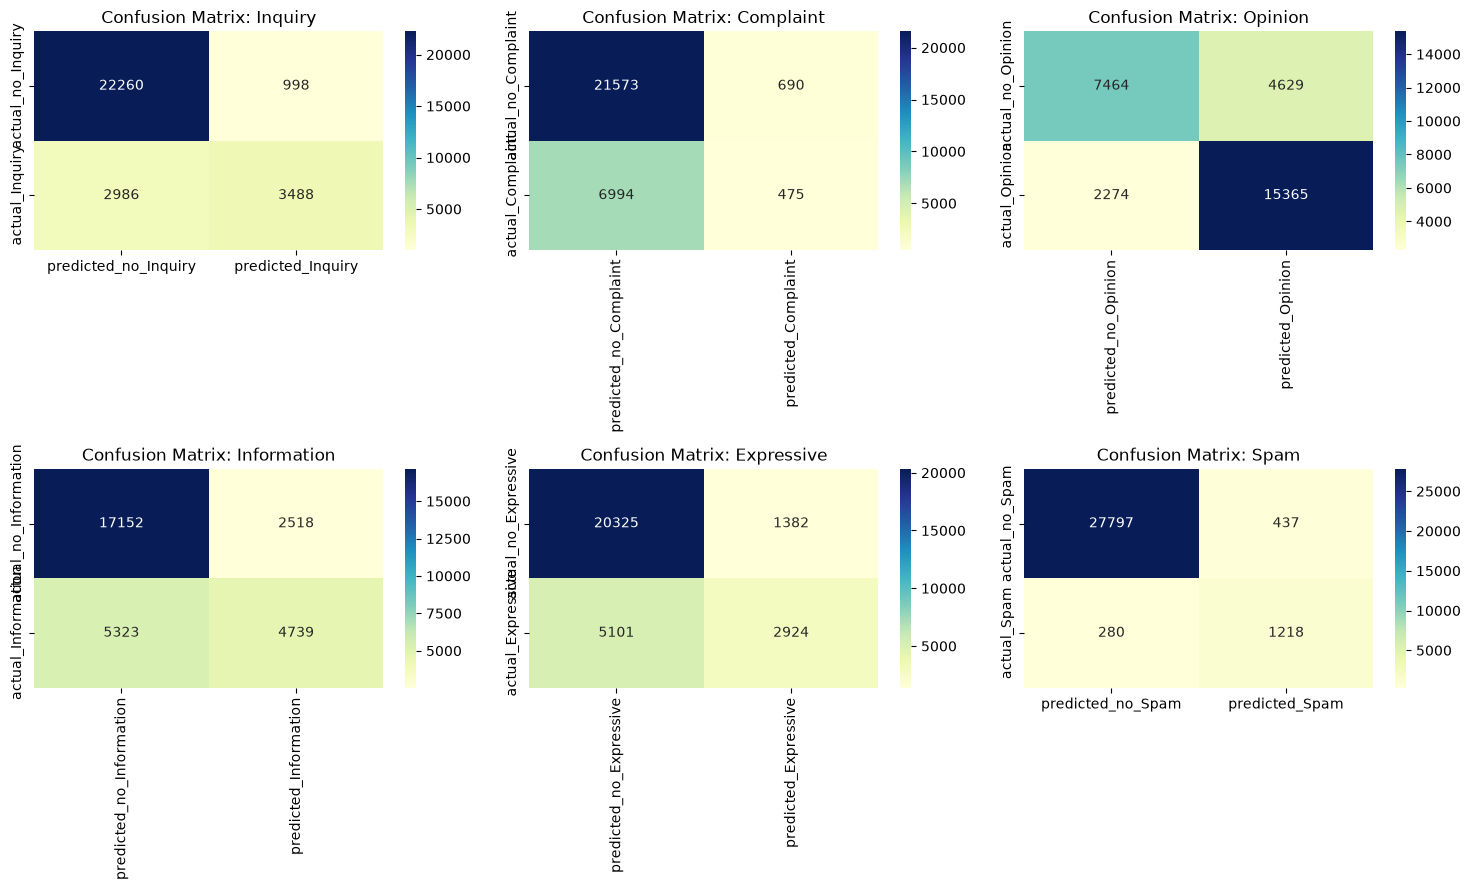


Overall Average F1 Score: 0.560



In [37]:
lr_f1_scores = evaluate_model("Logistic Regression", y_test, y_pred_lr, label_cols)

## 5.5 Random Forest Evaluation

We evaluate the Random Forest model across all intent categories to assess individual precision, recall, and F1-score balances.

RANDOM FOREST EVALUATION

--- Category: Inquiry ---
[21775  1483]
[2256  4218]
Accuracy:  0.874
Precision:  0.74
Recall:  0.652
F1 Score:  0.693

--- Category: Complaint ---
[22070  193]
[6991  478]
Accuracy:  0.758
Precision:  0.712
Recall:  0.064
F1 Score:  0.117

--- Category: Opinion ---
[7247  4846]
[1754  15885]
Accuracy:  0.778
Precision:  0.766
Recall:  0.901
F1 Score:  0.828

--- Category: Information ---
[17162  2508]
[4288  5774]
Accuracy:  0.771
Precision:  0.697
Recall:  0.574
F1 Score:  0.63

--- Category: Expressive ---
[20573  1134]
[5346  2679]
Accuracy:  0.782
Precision:  0.703
Recall:  0.334
F1 Score:  0.453

--- Category: Spam ---
[27833  401]
[251  1247]
Accuracy:  0.978
Precision:  0.757
Recall:  0.832
F1 Score:  0.793


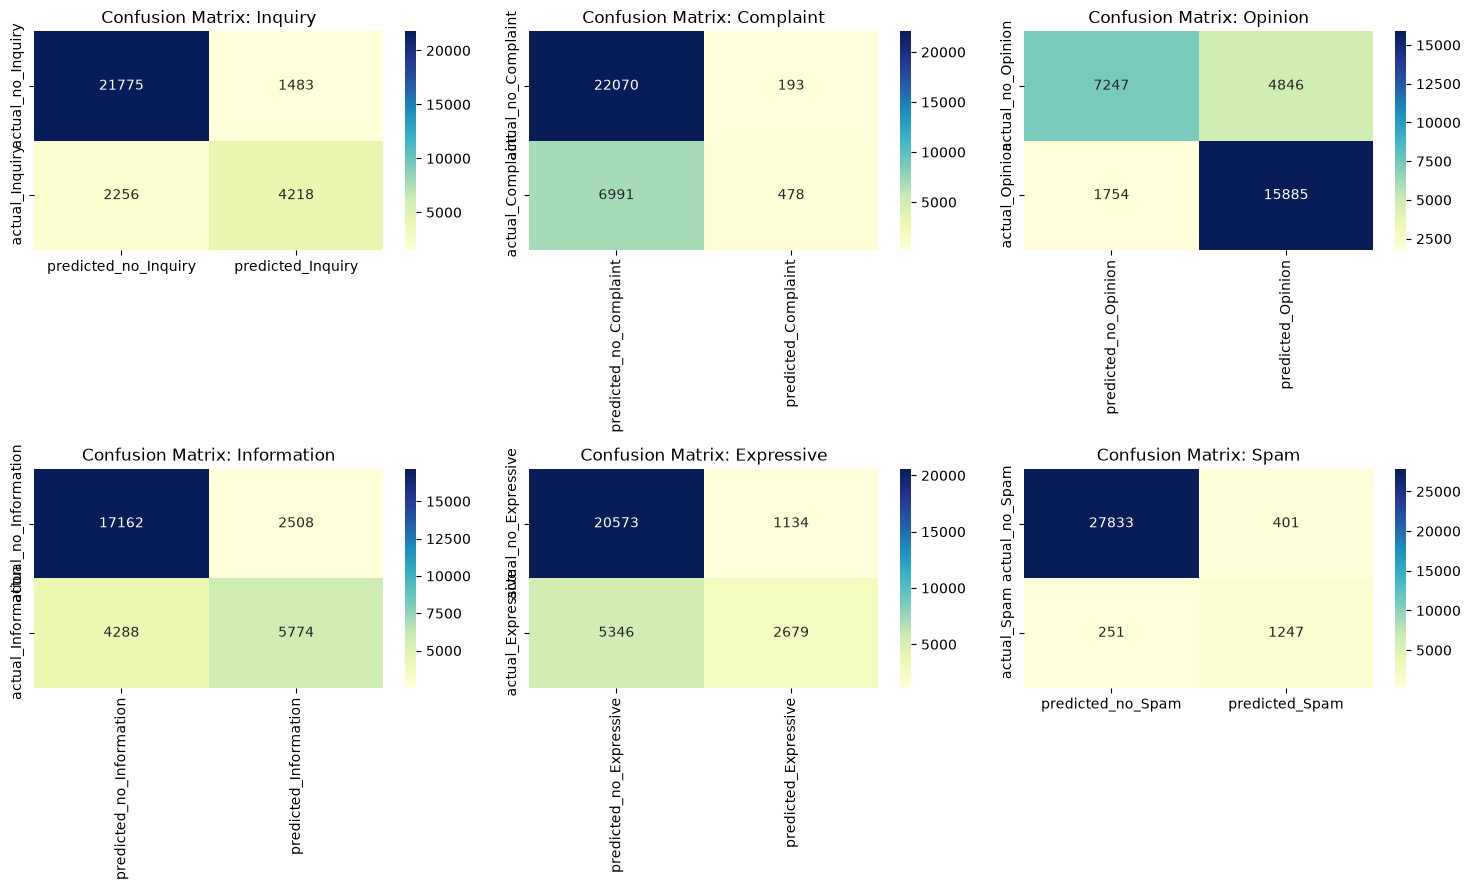


Overall Average F1 Score: 0.586



In [38]:
rf_f1_scores = evaluate_model("Random Forest", y_test, y_pred_rf, label_cols)

## 5.6 Model Comparison

We summarize and compare the F1-scores of both models across all communicative intent categories in a single comparison table to identify the best-performing architecture.

MODEL COMPARISON SUMMARY


,Category,Logistic Regression F1,Random Forest F1,Difference (RF - LR)
0,Inquiry,0.637,0.693,+0.056
1,Complaint,0.111,0.117,+0.006
2,Opinion,0.816,0.828,+0.012
3,Information,0.547,0.630,+0.083
4,Expressive,0.474,0.453,-0.021
5,Spam,0.773,0.793,+0.020


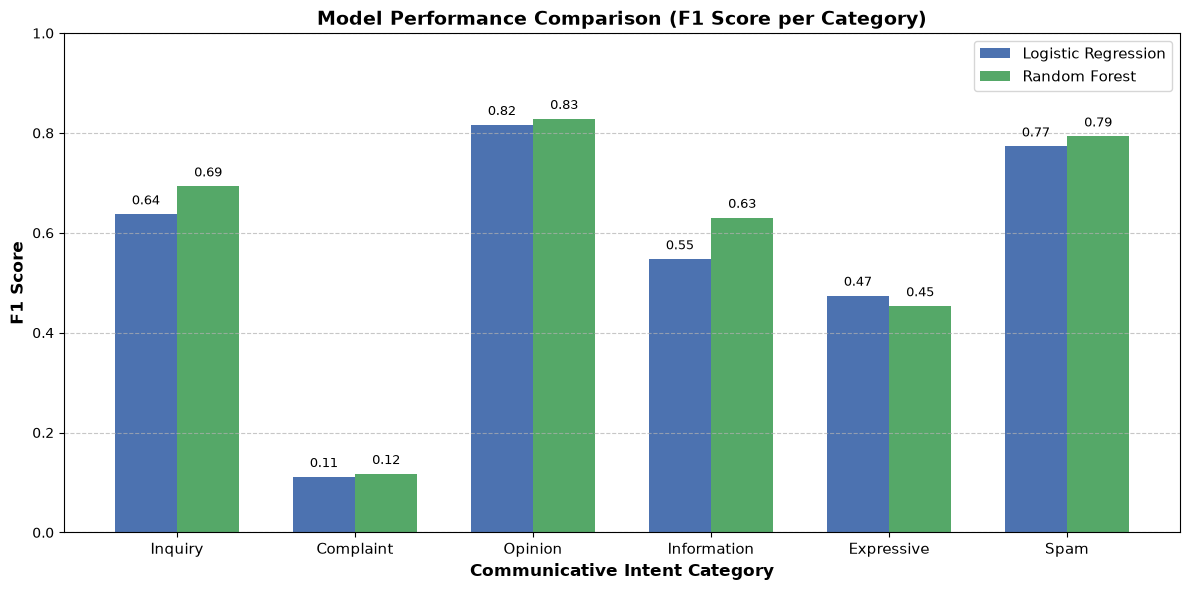

In [39]:
# Summary Comparison Table
print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
display(
    pd.DataFrame(
        {
            "Category": label_cols,
            "Logistic Regression F1": lr_f1_scores,
            "Random Forest F1": rf_f1_scores,
            "Difference (RF - LR)": np.array(rf_f1_scores) - np.array(lr_f1_scores),
        }
    ).style.format(
        {
            "Logistic Regression F1": "{:.3f}",
            "Random Forest F1": "{:.3f}",
            "Difference (RF - LR)": "{:+.3f}",
        }
    )
)

# Side-by-Side Presentation Bar Chart
plt.figure(figsize=(12, 6))
x = np.arange(len(label_cols))
width = 0.35

plt.bar(
    x - width / 2, lr_f1_scores, width, label="Logistic Regression", color="#4C72B0"
)
plt.bar(x + width / 2, rf_f1_scores, width, label="Random Forest", color="#55A868")

plt.xlabel("Communicative Intent Category", fontsize=12, fontweight="bold")
plt.ylabel("F1 Score", fontsize=12, fontweight="bold")
plt.title(
    "Model Performance Comparison (F1 Score per Category)",
    fontsize=14,
    fontweight="bold",
)
plt.xticks(x, label_cols, fontsize=11)
plt.ylim(0, 1.0)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add data labels on top of each bar
for i in range(len(label_cols)):
    plt.text(
        x[i] - width / 2,
        lr_f1_scores[i] + 0.02,
        f"{lr_f1_scores[i]:.2f}",
        ha="center",
        fontsize=9,
    )
    plt.text(
        x[i] + width / 2,
        rf_f1_scores[i] + 0.02,
        f"{rf_f1_scores[i]:.2f}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# 6.0 Predict Unseen Data

In this section, we deploy our saved feature extractors and trained classifiers to predict multi-label communicative intents on brand-new, unseen online forum posts in real time.

## 6.1 Load Saved Models from Joblib

We load the pre-trained FastText embedding model, Logistic Regression classifier, and Random Forest classifier from serialized Joblib disk files into memory.

In [40]:
# Load all saved model artifacts and feature extractors from joblib
loaded_ft = joblib.load("fasttext_model.joblib")
loaded_tfidf = joblib.load("tfidf_vectorizer.joblib")
loaded_lr = joblib.load("logistic_regression_model.joblib")
loaded_rf = joblib.load("random_forest_model.joblib")

# Build the TF-IDF lookup dictionary and default IDF weight for inference
loaded_idf_dict = dict(zip(loaded_tfidf.get_feature_names_out(), loaded_tfidf.idf_))
loaded_default_idf = float(np.mean(loaded_tfidf.idf_))

print("=" * 65)
print("ALL MODEL ARTIFACTS LOADED SUCCESSFULLY")
print("=" * 65)
print(f"FastText Model Vocab Size : {len(loaded_ft.wv.key_to_index):,}")
print(f"TF-IDF Feature Vocab Size : {len(loaded_idf_dict):,}")
print(f"Default (Mean) IDF Weight : {loaded_default_idf:.4f}")
print("Logistic Regression Model : Ready")
print("Random Forest Model       : Ready")
print("=" * 65)

ALL MODEL ARTIFACTS LOADED SUCCESSFULLY
FastText Model Vocab Size : 28,778
TF-IDF Feature Vocab Size : 26,847
Default (Mean) IDF Weight : 9.9199
Logistic Regression Model : Ready
Random Forest Model       : Ready


## 6.2 Interactive Real-Time Forum Comment Prediction Loop

We provide an interactive inference loop that feeds user-input Manglish/Malay forum text through the end-to-end preprocessing pipeline and displays real-time intent predictions.

In [ ]:
print("=" * 65)
print("INTERACTIVE UNSEEN FORUM INTENT PREDICTOR")
print("Type your Manglish comment to test.")
print("Type 'exit' or 'q' to stop.")
print("=" * 65)

while True:
    user_input = input("\nEnter forum comment: ").strip()

    # Exit condition
    if user_input.lower() in ["exit", "q", "quit"]:
        print("Exiting prediction loop. Done!")
        break

    if not user_input:
        print("Input cannot be empty. Please enter a valid sentence.")
        continue

    # =========================================================================
    # STAGE 1: Regex Cleaning, Entity Masking & Normalization
    # =========================================================================
    text = remove_quotes(user_input)
    text = remove_lowyat_edit_signatures(text)
    text = mask_urls(text)
    text = mask_phone_numbers(text)
    text = mask_prices(text)
    text = mask_times(text)
    text = convert_emojis(text)
    text = to_lower(text)
    text = strip_non_latin(text)
    text = reduce_elongated(text)

    # =========================================================================
    # STAGE 2: Sentence Tokenization, Slang Normalization & Punctuation Filtering
    # =========================================================================
    sentences = tokenize_sentences(text)
    norm_en = [normalize_slang_bulletproof(s) for s in sentences]
    norm_my = [normalize_malay_slang_bulletproof(s) for s in norm_en]
    
    # Word Tokenization
    raw_word_tokens = [tokenize_words(s) for s in norm_my]
    
    # Punctuation Filtering
    filtered_tokens = filter_tokens(raw_word_tokens)

    # =========================================================================
    # STAGE 3: Language Identification, Stemming/Lemmatization & Stopword Removal
    # =========================================================================
    classified_tokens = classify_post_lang(filtered_tokens)
    stem_lemma_tokens = process_post_stem_lemma(classified_tokens)
    clean_stopped_tokens = filter_post_stopwords(stem_lemma_tokens)
    
    # Flatten to 1D list of cleaned tokens
    tokens = flatten_post_to_tokens(clean_stopped_tokens)

    # =========================================================================
    # STAGE 4: TF-IDF Weighted FastText Vector Extraction
    # =========================================================================
    if tokens:
        vec = extract_tfidf_weighted_vector(
            tokens, loaded_ft, loaded_idf_dict, loaded_default_idf
        ).reshape(1, -1)
    else:
        vec = np.zeros((1, 100))

    # =========================================================================
    # STAGE 5: Multi-Label Intent Prediction
    # =========================================================================
    lr_pred = loaded_lr.predict(vec)[0]
    rf_pred = loaded_rf.predict(vec)[0]

    lr_results = [label_cols[i] for i, val in enumerate(lr_pred) if val == 1]
    rf_results = [label_cols[i] for i, val in enumerate(rf_pred) if val == 1]

    # Output predictions
    print("-" * 50)
    print("Cleaned Tokens      :", tokens)
    print("Logistic Regression :", lr_results if lr_results else ["Neutral / None"])
    print("Random Forest       :", rf_results if rf_results else ["Neutral / None"])
    print("-" * 50)

INTERACTIVE UNSEEN FORUM INTENT PREDICTOR
Type your Manglish comment to test.
Type 'exit' or 'q' to stop.



Enter forum comment:  i just got 2 weeks of holiday!


--------------------------------------------------
Cleaned Tokens      : ['get', 'week', 'holiday', '!']
Logistic Regression : ['Expressive']
Random Forest       : ['Expressive']
--------------------------------------------------


C:\Users\ThinkPad\anaconda3\envs\nlp_project\Lib\site-packages\malaya\model\stem.py:28: FutureWarning: Possible nested set at position 3
  or re.findall(_expressions['ic'], word.lower())



Enter forum comment:  that's kinda impressive


...

--------------------------------------------------
Cleaned Tokens      : ['bugging', 'non', 'stop']
Logistic Regression : ['Complaint', 'Opinion']
Random Forest       : ['Opinion']
--------------------------------------------------



Enter forum comment:  this phone is bugged


--------------------------------------------------
Cleaned Tokens      : ['phone', 'bugged']
Logistic Regression : ['Information']
Random Forest       : ['Information']
--------------------------------------------------



Enter forum comment:  this computer is bad


--------------------------------------------------
Cleaned Tokens      : ['computer', 'teruk']
Logistic Regression : ['Complaint', 'Opinion', 'Information']
Random Forest       : ['Opinion']
--------------------------------------------------
